# 01 - Exploratory Data Analysis (Stage 3)
**Dataset:** `data/raw/online_shoppers_intention_synthetic_missing.xlsx` - Online Shoppers Purchasing Intention (UCI) with MCAR missing values in 4 columns.
**Goal:** understand structure, missing values, duplicates, outliers, class imbalance, relationships and leakage risk. Every observation here must be written down because it justifies a later preprocessing decision.

Run cells top to bottom. Figures are saved automatically to `reports/figures`, tables to `reports/tables`.

In [1]:
import os, sys, warnings
from pathlib import Path

# make `import src...` work no matter where Jupyter was started
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

# os.environ["FAST"] = "1"   # <- uncomment for a quick dry run (small sample, 3 folds). Must be BEFORE the src imports.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif

from src.preprocessing import (CATEGORICAL_COLS, LEAKAGE_SUSPECTS, MISSING_CATEGORICAL, MISSING_NUMERIC,
                               NUMERIC_COLS, TARGET, TABLE_DIR, basic_clean, load_modified)
from src.evaluate import save_fig, save_table

sns.set_theme(style="whitegrid")
raw = load_modified()
df = basic_clean(raw)
print("Shape:", df.shape)
df.head()

Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0.0,0.0,0.0,0.0,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0.0,0.0,0.0,0.0,2.0,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0.0,0.0,0.0,0.0,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0.0,0.0,0.0,0.0,2.0,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0.0,0.0,0.0,0.0,10.0,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


## 1. Structure and types

In [2]:
structure = pd.DataFrame({"dtype": df.dtypes.astype(str), "n_unique": df.nunique(),
                          "n_missing": df.isna().sum()}).reset_index(names="column")
save_table(structure, "eda_structure")
display(structure)
desc = df[NUMERIC_COLS].describe().T.reset_index(names="column")
save_table(desc, "eda_numeric_describe")
display(desc)

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\eda_structure.csv


,column,dtype,n_unique,n_missing
0,Administrative,float64,27,0
1,Administrative_Duration,float64,3175,740
2,Informational,float64,17,0
3,Informational_Duration,float64,1258,0
4,ProductRelated,float64,311,0
5,ProductRelated_Duration,float64,9121,616
6,BounceRates,float64,1783,863
7,ExitRates,float64,4777,0
8,PageValues,float64,2704,0
9,SpecialDay,float64,6,0


[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\eda_numeric_describe.csv


,column,count,mean,std,min,25%,50%,75%,max
0,Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
1,Administrative_Duration,11590.0,81.123862,177.701873,0.0,0.000000,7.000000,92.908333,3398.750000
2,Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
3,Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
4,ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
5,ProductRelated_Duration,11714.0,1189.579352,1914.333519,0.0,184.525000,597.629027,1448.884523,63973.522230
6,BounceRates,11467.0,0.022138,0.048436,0.0,0.000000,0.003101,0.016667,0.200000
7,ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
8,PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
9,SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


## 2. Missing values
Four columns contain missing values. We check how much, where, and whether the pattern looks random (MCAR).

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\eda_missing_counts.csv


,column,missing,pct
0,BounceRates,863,7.0
1,Administrative_Duration,740,6.0
2,ProductRelated_Duration,616,5.0
3,VisitorType,493,4.0


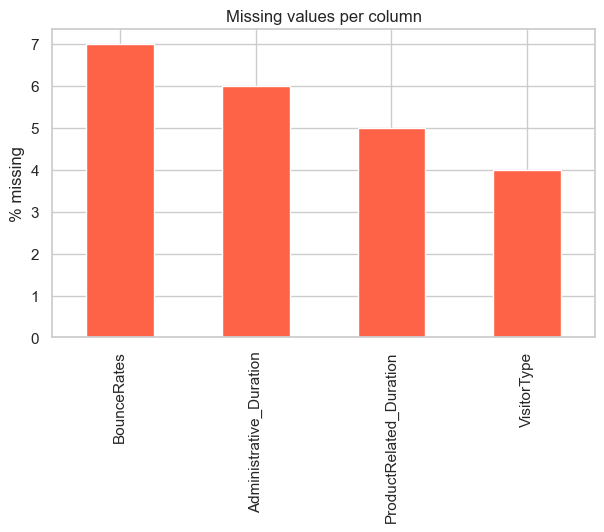

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\eda_missing_bar.png


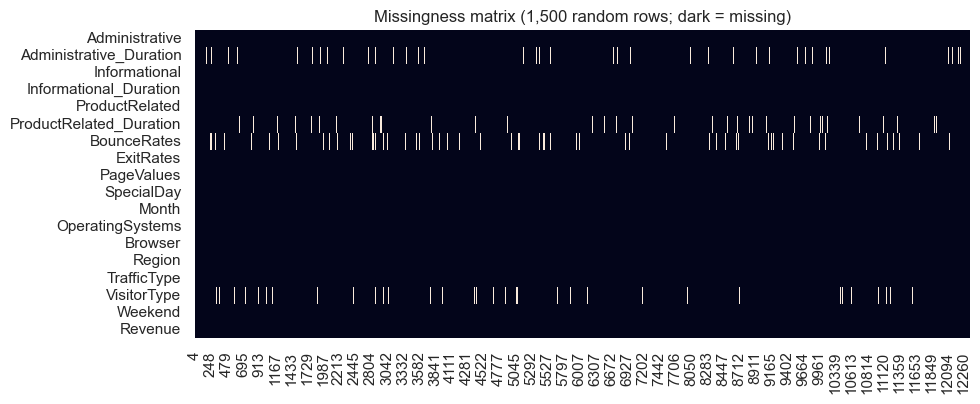

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\eda_missing_matrix.png


In [3]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_tbl = pd.DataFrame({"missing": miss, "pct": (miss / len(df) * 100).round(2)}).reset_index(names="column")
save_table(miss_tbl, "eda_missing_counts")
display(miss_tbl)

fig, ax = plt.subplots(figsize=(7, 4))
(miss / len(df) * 100).plot.bar(ax=ax, color="tomato")
ax.set_ylabel("% missing"); ax.set_title("Missing values per column")
save_fig(fig, "eda_missing_bar")

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.sample(1500, random_state=1).sort_index().isna().T, cbar=False, ax=ax, yticklabels=True)
ax.set_title("Missingness matrix (1,500 random rows; dark = missing)")
save_fig(fig, "eda_missing_matrix")

In [4]:
# MCAR check: is "missing" related to the target or to Month?  p > 0.05  => no evidence against MCAR
rows = []
for c in MISSING_NUMERIC + MISSING_CATEGORICAL:
    flag = df[c].isna()
    for other in [TARGET, "Month"]:
        p = chi2_contingency(pd.crosstab(flag, df[other]))[1]
        rows.append({"column": c, "compared_with": other, "chi2_p_value": round(p, 4),
                     "evidence_against_MCAR": p < 0.05})
mcar = pd.DataFrame(rows)
save_table(mcar, "eda_mcar_check")
mcar

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\eda_mcar_check.csv


,column,compared_with,chi2_p_value,evidence_against_MCAR
0,Administrative_Duration,Revenue,0.7540,False
1,Administrative_Duration,Month,0.4755,False
2,ProductRelated_Duration,Revenue,0.3133,False
3,ProductRelated_Duration,Month,0.5782,False
4,BounceRates,Revenue,0.9965,False
5,BounceRates,Month,0.9450,False
6,VisitorType,Revenue,0.3882,False
7,VisitorType,Month,0.8660,False


## 3. Duplicates and class imbalance

Duplicated rows: 92 (0.75%)
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\eda_duplicates.csv
{0: 10422, 1: 1908} {0: 0.845, 1: 0.155}


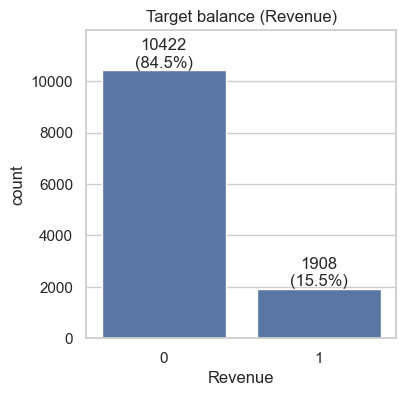

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\eda_target_balance.png


In [5]:
n_dup = int(df.duplicated().sum())
print(f"Duplicated rows: {n_dup} ({n_dup / len(df):.2%})")
save_table(pd.DataFrame({"duplicated_rows": [n_dup]}), "eda_duplicates")

vc = df[TARGET].value_counts()
print(vc.to_dict(), (vc / len(df)).round(3).to_dict())
fig, ax = plt.subplots(figsize=(4, 4))
sns.countplot(x=TARGET, data=df, ax=ax)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}\n({p.get_height() / len(df):.1%})", (p.get_x() + .4, p.get_height()),
                ha="center", va="bottom")
ax.set_title("Target balance (Revenue)"); ax.set_ylim(0, vc.max() * 1.15)
save_fig(fig, "eda_target_balance")

## 4. Distributions and outliers

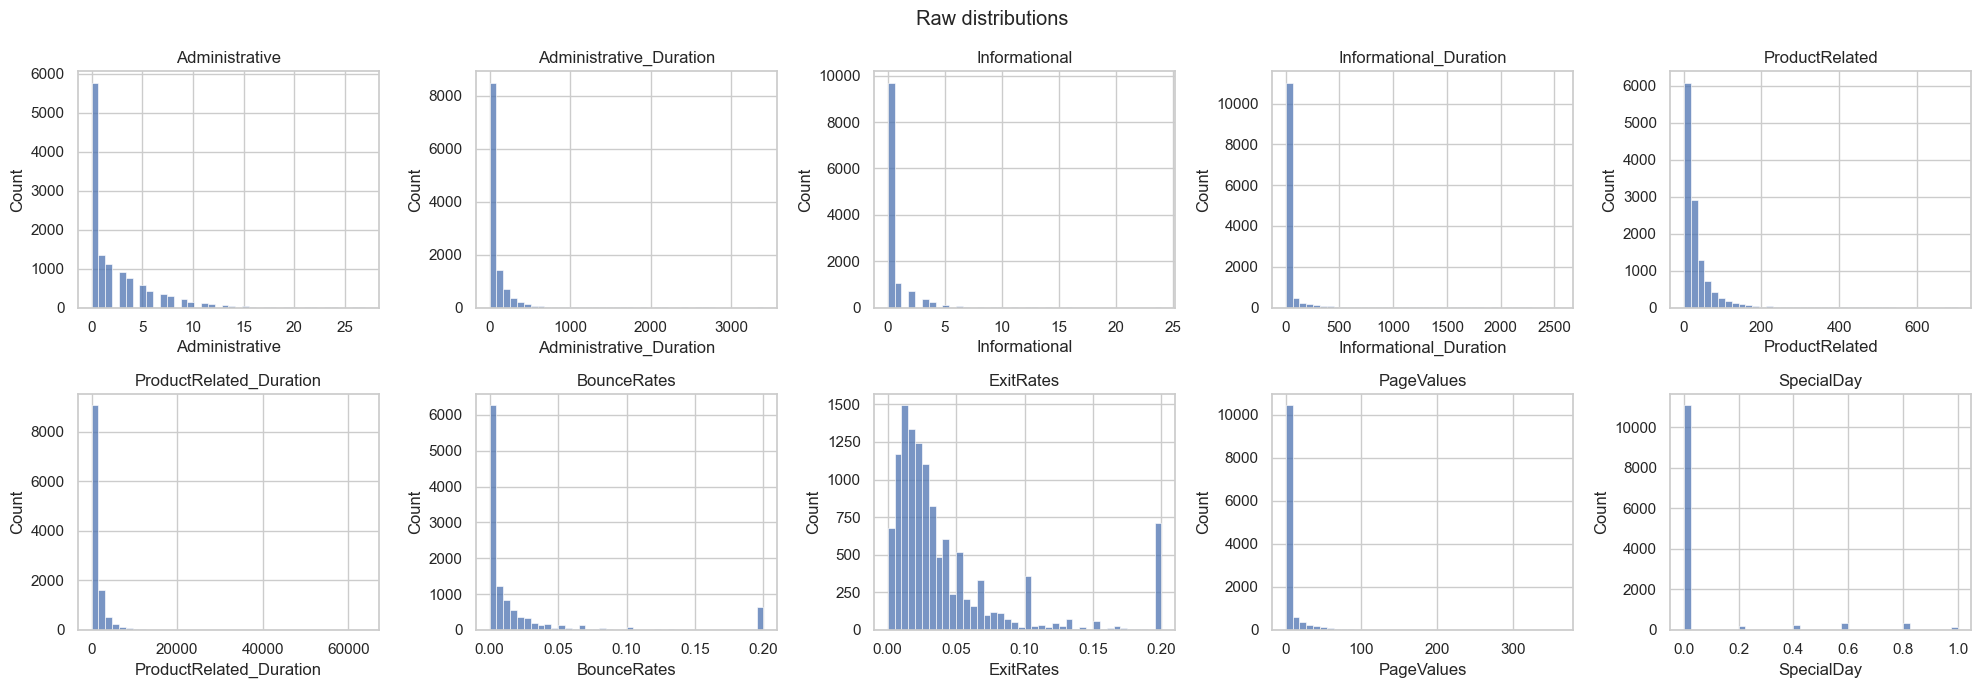

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\eda_hist_raw.png


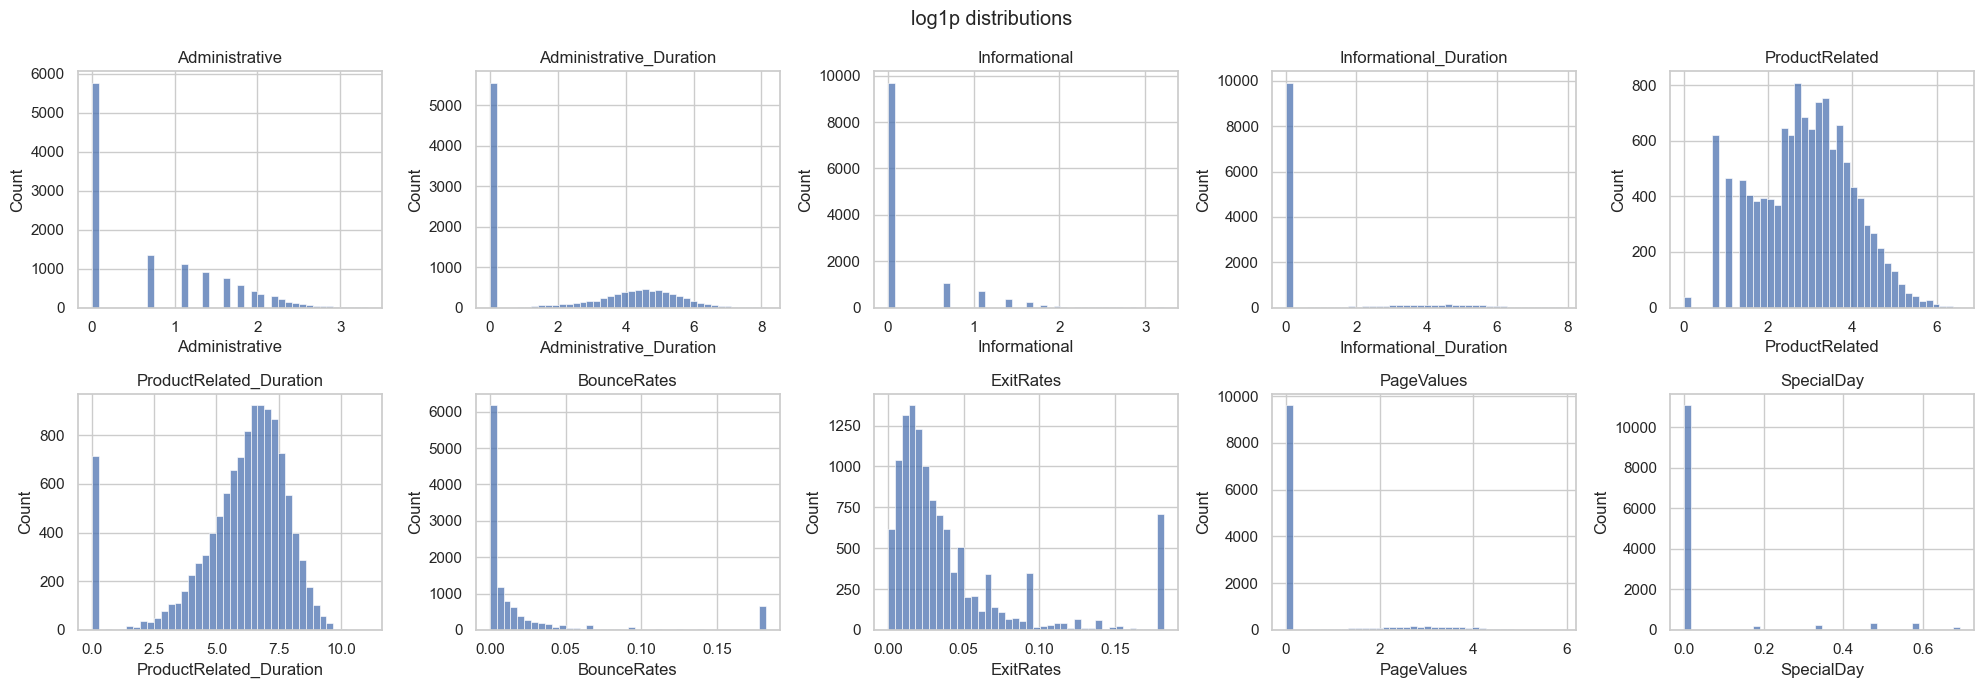

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\eda_hist_log1p.png


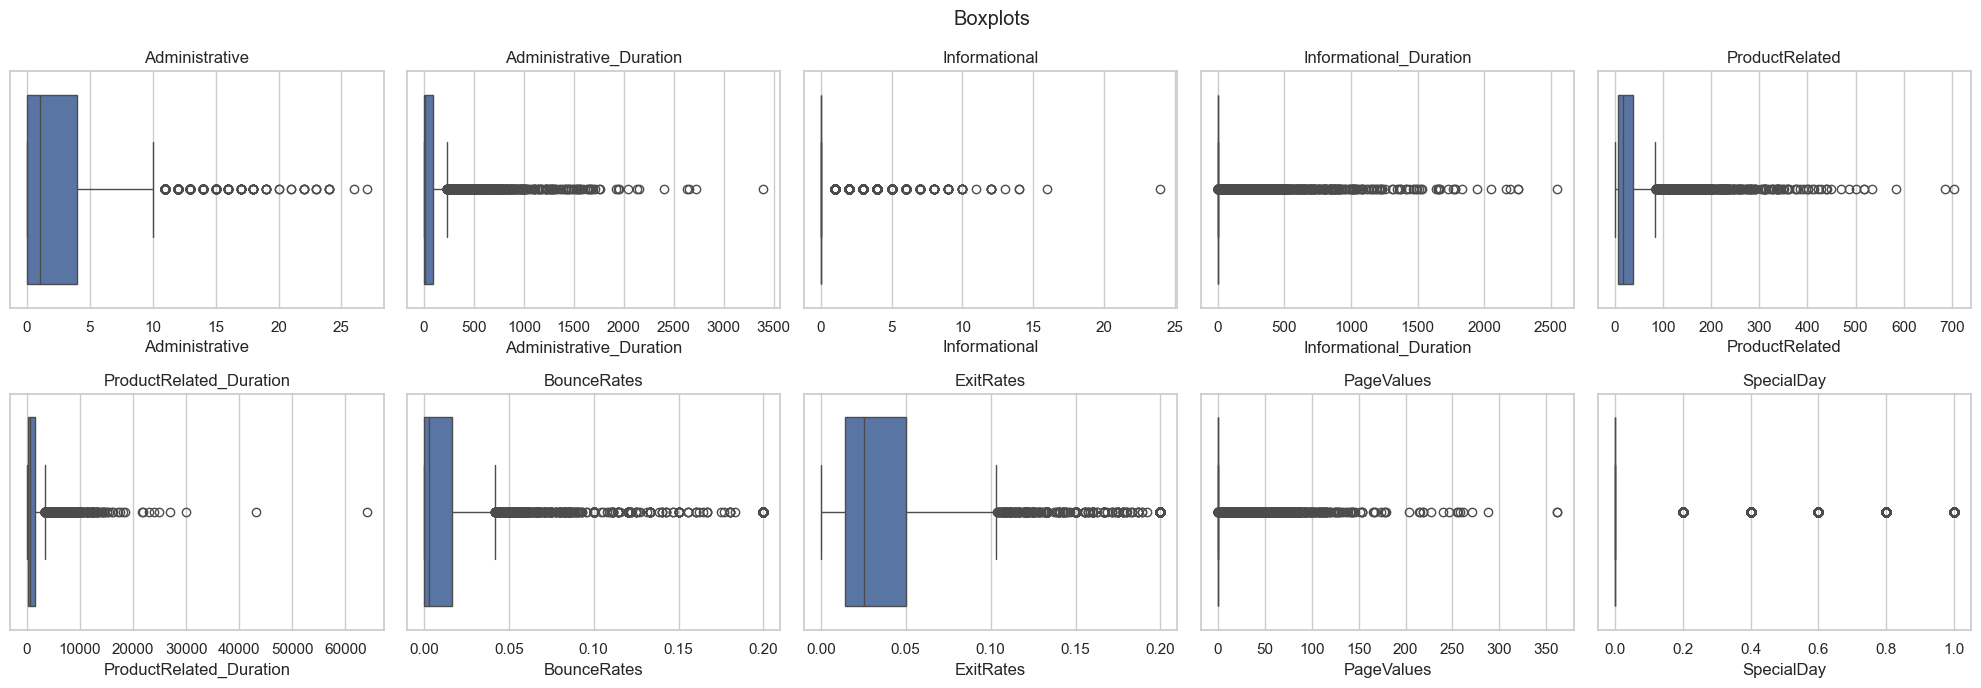

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\eda_boxplots.png


In [6]:
def grid(fn, title):
    fig, axes = plt.subplots(2, 5, figsize=(20, 7))
    for ax, c in zip(axes.ravel(), NUMERIC_COLS):
        fn(ax, c); ax.set_title(c)
    fig.suptitle(title); fig.tight_layout()
    return fig

save_fig(grid(lambda ax, c: sns.histplot(df[c].dropna(), bins=40, ax=ax), "Raw distributions"), "eda_hist_raw")
save_fig(grid(lambda ax, c: sns.histplot(np.log1p(df[c].dropna()), bins=40, ax=ax), "log1p distributions"), "eda_hist_log1p")
save_fig(grid(lambda ax, c: sns.boxplot(x=df[c], ax=ax), "Boxplots"), "eda_boxplots")

In [7]:
out_rows = []
for c in NUMERIC_COLS:
    s = df[c].dropna()
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    n_out = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
    out_rows.append({"column": c, "skew": round(s.skew(), 2), "zero_share_%": round((s == 0).mean() * 100, 1),
                     "IQR_outliers": n_out, "IQR_outlier_%": round(n_out / len(s) * 100, 1),
                     "p99": s.quantile(.99), "max": s.max()})
outliers = pd.DataFrame(out_rows)
save_table(outliers, "eda_outliers")
outliers

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\eda_outliers.csv


,column,skew,zero_share_%,IQR_outliers,IQR_outlier_%,p99,max
0,Administrative,1.96,46.8,404,3.3,14.000000,27.000000
1,Administrative_Duration,5.61,47.9,1116,9.6,832.433778,3398.750000
2,Informational,4.04,78.7,2631,21.3,6.000000,24.000000
3,Informational_Duration,7.58,80.5,2405,19.5,716.390000,2549.375000
4,ProductRelated,4.34,0.3,987,8.0,221.000000,705.000000
5,ProductRelated_Duration,7.40,6.1,926,7.9,8697.531980,63973.522230
6,BounceRates,2.95,44.8,1439,12.5,0.200000,0.200000
7,ExitRates,2.15,0.6,1099,8.9,0.200000,0.200000
8,PageValues,6.38,77.9,2730,22.1,85.498490,361.763742
9,SpecialDay,3.30,89.9,1251,10.1,1.000000,1.000000


**Write down:** durations and counts are strongly right-skewed with many zeros, so the IQR rule flags many "outliers" that are real behaviour (long sessions), not errors. Plan: log1p transform or 1-99% winsorising rather than deleting rows (compared in notebook 02).

## 5. Relationships with the target

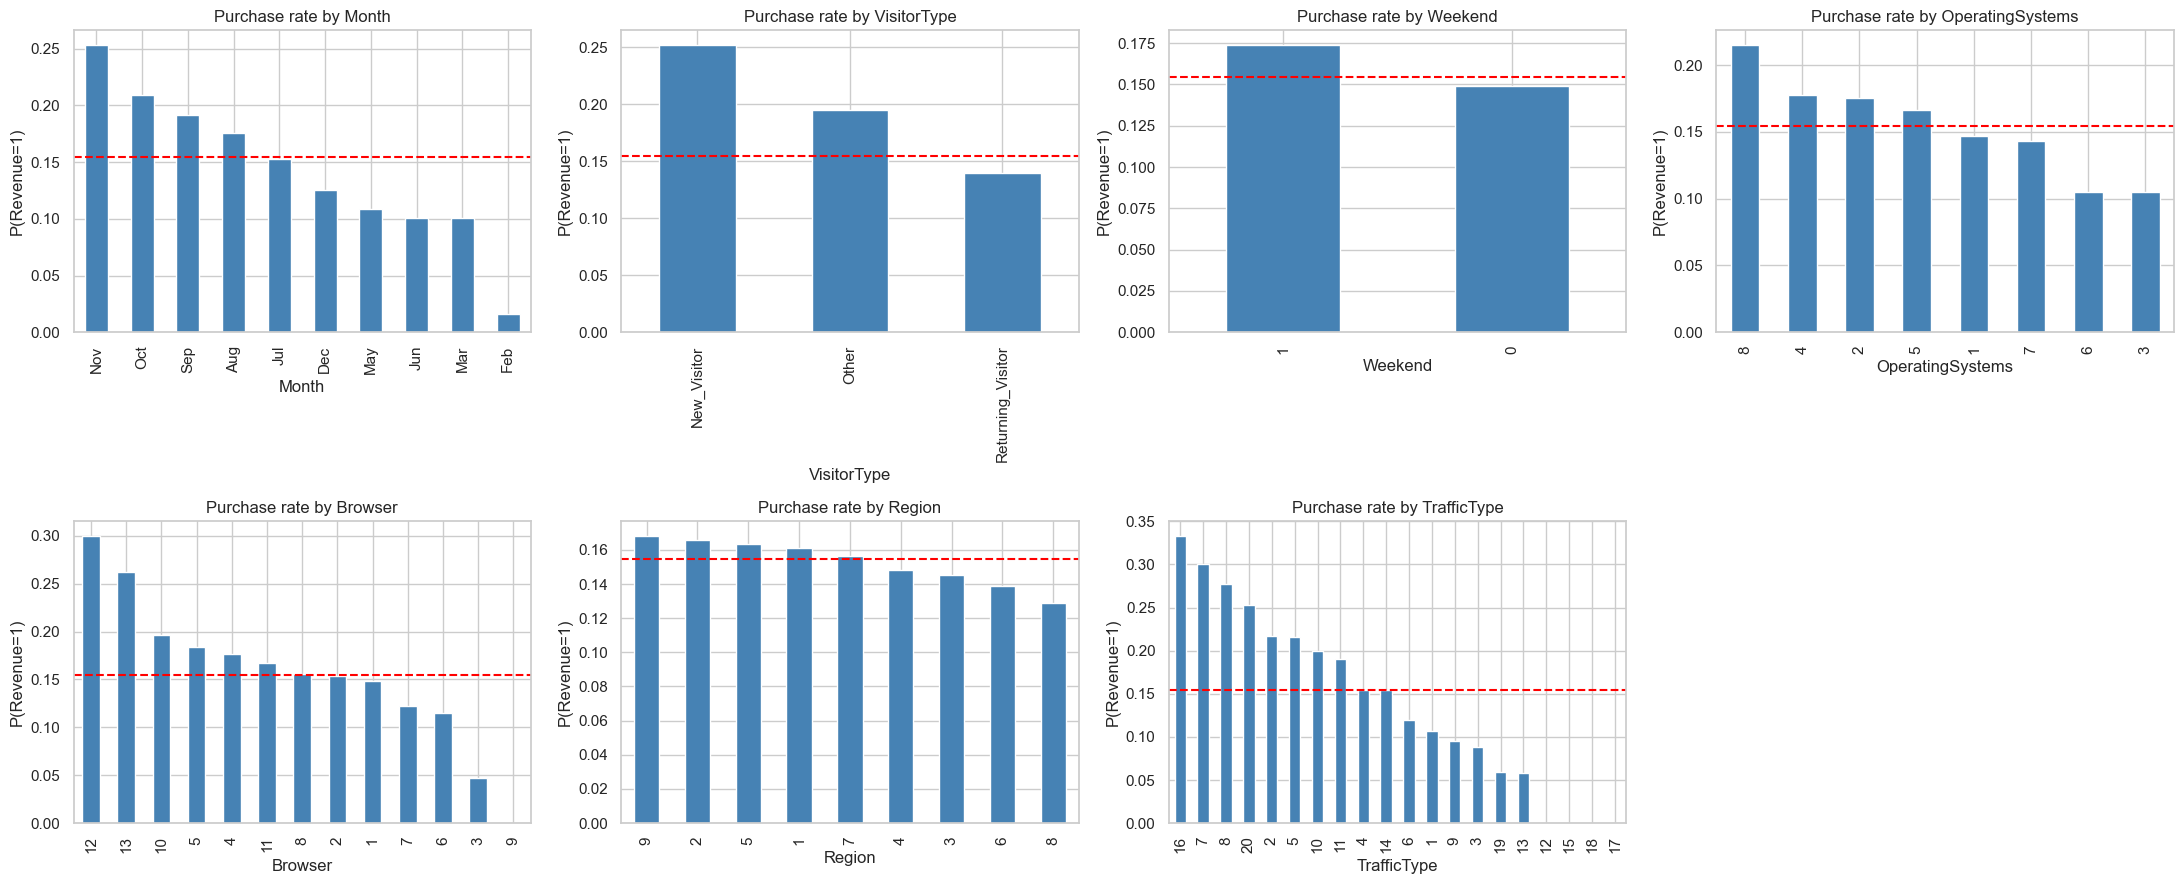

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\eda_purchase_rate_by_category.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for ax, c in zip(axes.ravel(), CATEGORICAL_COLS):
    rate = df.groupby(c)[TARGET].mean().sort_values(ascending=False)
    rate.plot.bar(ax=ax, color="steelblue")
    ax.axhline(df[TARGET].mean(), color="red", ls="--")
    ax.set_title(f"Purchase rate by {c}"); ax.set_ylabel("P(Revenue=1)")
axes.ravel()[-1].axis("off")
fig.tight_layout(); save_fig(fig, "eda_purchase_rate_by_category")

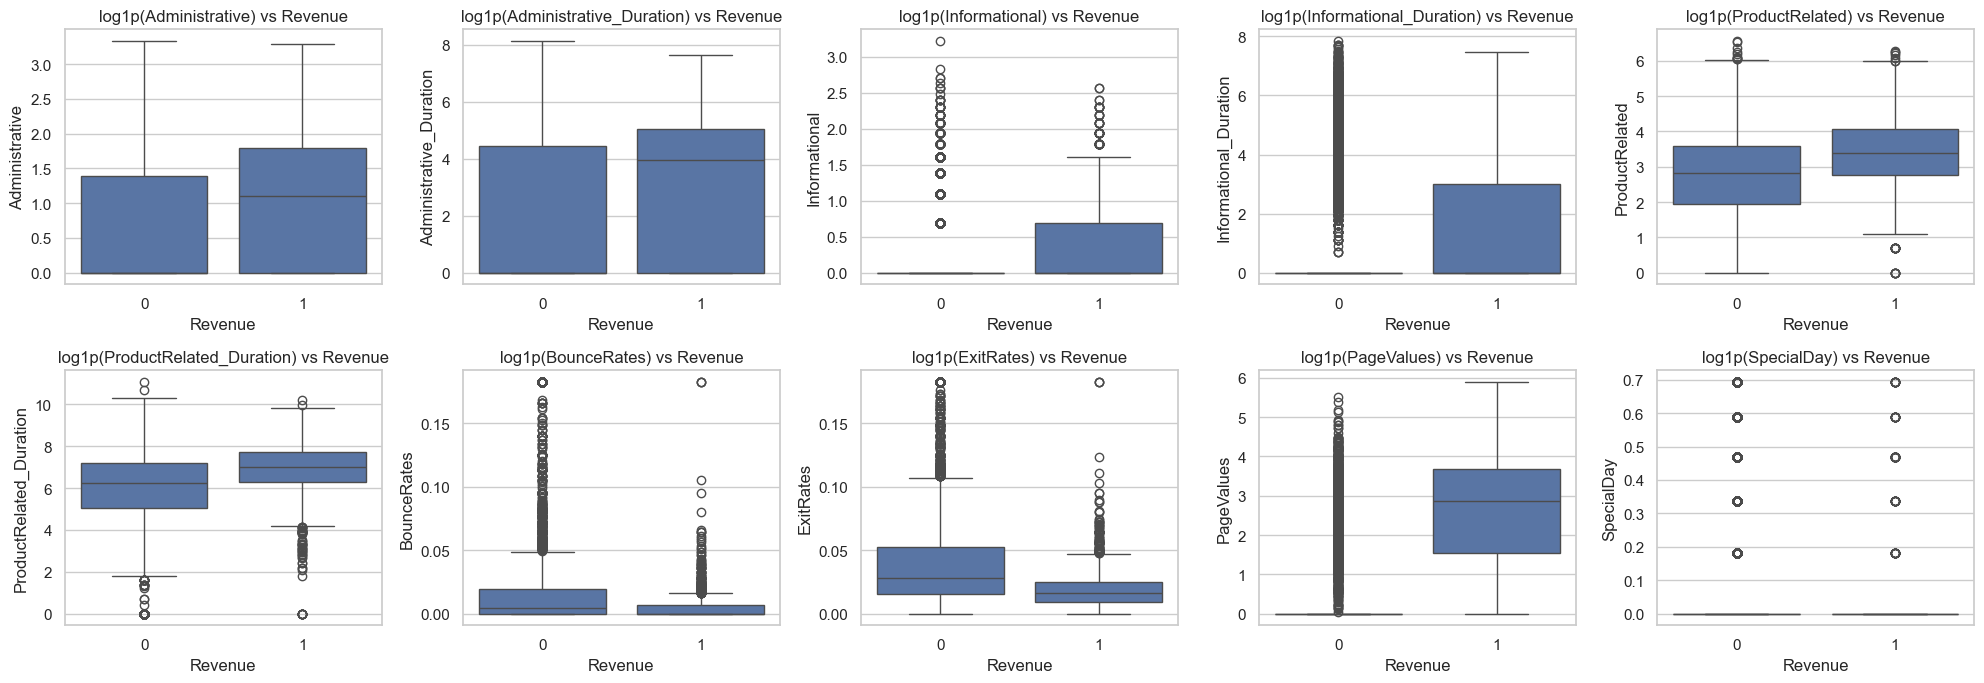

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\eda_numeric_vs_target.png


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, c in zip(axes.ravel(), NUMERIC_COLS):
    sns.boxplot(x=TARGET, y=np.log1p(df[c]), data=df, ax=ax); ax.set_title(f"log1p({c}) vs Revenue")
fig.tight_layout(); save_fig(fig, "eda_numeric_vs_target")

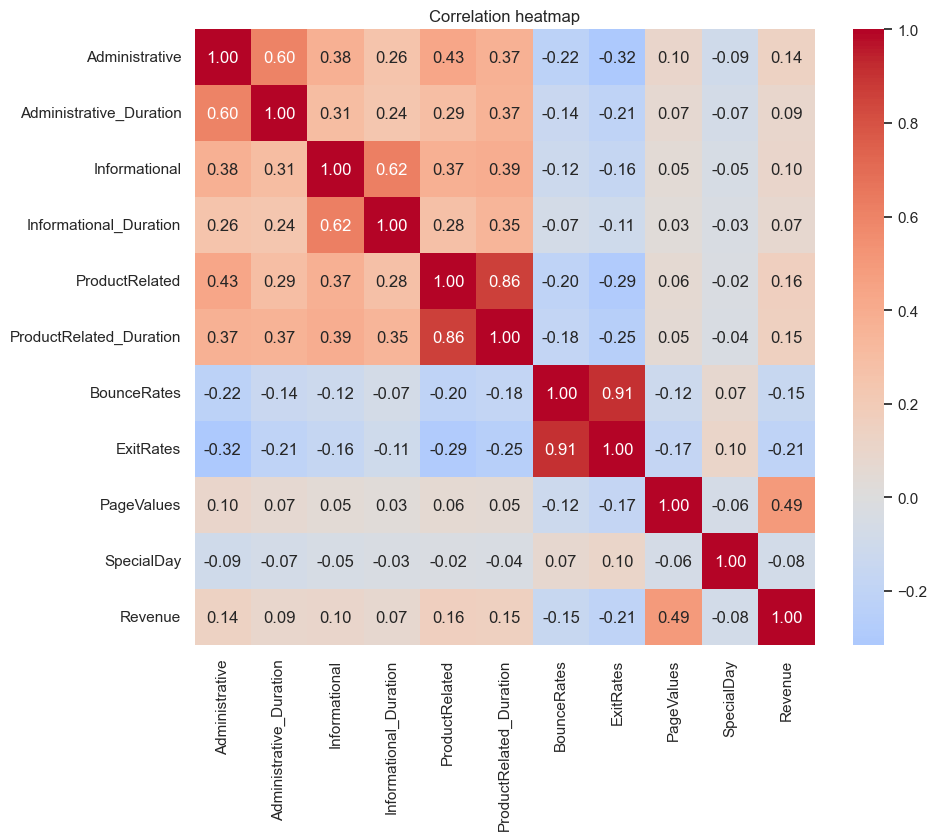

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\eda_correlation_heatmap.png
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\eda_corr_with_target.csv


,feature,corr_with_revenue
0,PageValues,0.492569
1,ExitRates,-0.207071
2,ProductRelated,0.158538
3,ProductRelated_Duration,0.152310
4,BounceRates,-0.149882
5,Administrative,0.138917
6,Informational,0.095200
7,Administrative_Duration,0.090674
8,SpecialDay,-0.082305
9,Informational_Duration,0.070345


In [10]:
corr = df[NUMERIC_COLS + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax); ax.set_title("Correlation heatmap")
save_fig(fig, "eda_correlation_heatmap")
corr_t = (corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
          .rename("corr_with_revenue").rename_axis("feature").reset_index())
save_table(corr_t, "eda_corr_with_target")
corr_t

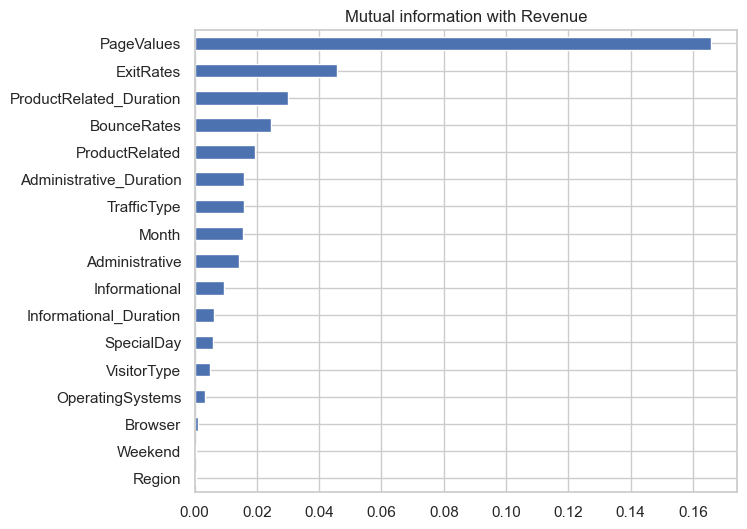

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\eda_mutual_information.png
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\eda_mutual_info.csv


In [11]:
# mutual information (quick relevance ranking; median-filled copy used ONLY here for EDA)
tmp = df.copy()
for c in NUMERIC_COLS:
    tmp[c] = tmp[c].fillna(tmp[c].median())
for c in CATEGORICAL_COLS:
    tmp[c] = tmp[c].fillna("Unknown").astype("category").cat.codes
cols = NUMERIC_COLS + CATEGORICAL_COLS
mi = pd.Series(mutual_info_classif(tmp[cols], tmp[TARGET], discrete_features=[False] * len(NUMERIC_COLS) + [True] * len(CATEGORICAL_COLS),
                                   random_state=42), index=cols).sort_values()
fig, ax = plt.subplots(figsize=(7, 6)); mi.plot.barh(ax=ax); ax.set_title("Mutual information with Revenue")
save_fig(fig, "eda_mutual_information")
save_table(mi.sort_values(ascending=False).rename("mutual_info").rename_axis("feature").reset_index(), "eda_mutual_info")

## 6. Data-leakage assessment

In [12]:
notes = f"""# Data-leakage assessment
Feature leakage risk (target proxies / only known at session end):
- PageValues: average value of pages visited before a transaction; strongest predictor; computed by Google Analytics from
  e-commerce transactions so it partly encodes the outcome. Tested by dropping it in notebook 02.
- ExitRates / BounceRates: session-level aggregates, complete only when the session ends.
Procedural leakage and prevention:
- Imputers, scalers, encoders, capping quantiles, feature selection and SMOTE are fitted inside a Pipeline (training folds only).
- Stratified split BEFORE any fitting; duplicates removed before splitting.
- Missingness is unrelated to Revenue (chi-square, eda_mcar_check.csv).
Suspect columns: {LEAKAGE_SUSPECTS}
"""
(TABLE_DIR / "eda_leakage_notes.md").write_text(notes)
print(notes)

# Data-leakage assessment
Feature leakage risk (target proxies / only known at session end):
- PageValues: average value of pages visited before a transaction; strongest predictor; computed by Google Analytics from
  e-commerce transactions so it partly encodes the outcome. Tested by dropping it in notebook 02.
- ExitRates / BounceRates: session-level aggregates, complete only when the session ends.
Procedural leakage and prevention:
- Imputers, scalers, encoders, capping quantiles, feature selection and SMOTE are fitted inside a Pipeline (training folds only).
- Stratified split BEFORE any fitting; duplicates removed before splitting.
- Missingness is unrelated to Revenue (chi-square, eda_mcar_check.csv).
Suspect columns: ['PageValues', 'ExitRates', 'BounceRates']



## 7. Findings checklist (fill in for your report and viva)
- Class balance: ~15.5% buyers -> accuracy misleading; use F1 / recall / PR-AUC.
- Missing: 4 columns, 4-7%, MCAR (p-values in table) -> imputation is valid, deletion wastes ~20% of rows.
- Skewed, zero-inflated numerics -> log1p / winsorise.
- Strongest relationships: PageValues, ExitRates, Month (Nov peak), VisitorType.
- Leakage: PageValues decision; pipeline-only fitting.